# Fitting a Line: What Does "Best" Mean?

> *Adapted from teaching notebooks contributed by **Lei Qian**, who developed the regression
> material for this course.*

**This notebook is self-contained; it assumes only that you can plot points and a line.**

Here is a real dataset: someone recorded how fast striped ground crickets chirp at various
temperatures. The points obviously trend upward, warmer means faster chirping, and you could draw a
straight line through them by eye.

But *which* line? Before any calculus, we have to answer a more basic question: **what makes one line
better than another?** Once "best" is defined precisely, finding it becomes a calculation.

## Learning objectives

- Express a straight-line model as $y = b_0 + b_1 x$ and identify its two parameters.
- Define the **residual** of a data point and explain why residuals get **squared**.
- Compute the least-squares **slope and intercept** from the data.

## Background

The **simple linear regression** model says the relationship is a straight line plus an error:

$$y = b_0 + b_1 x + \epsilon$$

$b_0$ is the **intercept** (where the line meets the vertical axis) and $b_1$ is the **slope**. For
each observed point, the **residual** is the vertical gap between the actual value and the line's
prediction:

$$e_i = y_i - \hat{y}_i = y_i - (b_0 + b_1 x_i)$$

A good line makes those gaps small. But small *how*? Adding them up fails immediately, positive and
negative residuals cancel, so a terrible line can total zero. **Squaring** first fixes that, and
punishes large misses more than small ones. So we minimize

$$\text{SSE} = \sum_i e_i^2 = \sum_i \left(y_i - b_0 - b_1 x_i\right)^2$$

This is the **least squares** criterion. Minimizing it gives closed-form answers:

$$b_1 = \frac{\sum (x_i - \bar{x})(y_i - \bar{y})}{\sum (x_i - \bar{x})^2}, \qquad b_0 = \bar{y} - b_1\bar{x}$$

## This notebook covers

1. The data.
2. Three candidate lines: which is best?
3. Residuals, and why we square them.
4. The least-squares answer, computed from the formulas.

**Prerequisites:** none, this notebook starts from scratch.

**Dataset:** `slr02.csv`, chirps per second vs temperature (°F) for the striped ground cricket,
from the shared dataset library.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)

plt.style.use('dark_background')

import warnings
warnings.filterwarnings('ignore')

# shared display helper (msds520_helpers.py lives at the MSDS 520 course root).
# notebooks sit two folders below it, so '../..' points back to it.
import sys
sys.path.append('../..')
import msds520_helpers as helpers
# plotting helper: draw x-y graphs like the usual coordinate plane
def center_axes(ax):
    ax.spines['left'].set_position('zero')     # y-axis through x = 0
    ax.spines['bottom'].set_position('zero')   # x-axis through y = 0
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

## 1. The data

Fifteen observations. The file's first two rows are descriptive text rather than data, so they are
skipped on load.

In [2]:
# the file's first three lines are a header plus two lines of description, not data
crickets = pd.read_csv(helpers.data('MSDS 520 Calculus/slr02.csv'), skiprows=3,
                       names=['chirps', 'temperature'])
print(f"{len(crickets)} observations")
crickets

15 observations


,chirps,temperature
0,20.0,88.6
1,16.0,71.6
2,19.8,93.3
3,18.4,84.3
4,17.1,80.6
5,15.5,75.2
6,14.7,69.7
7,17.1,82.0
8,15.4,69.4
9,16.2,83.3


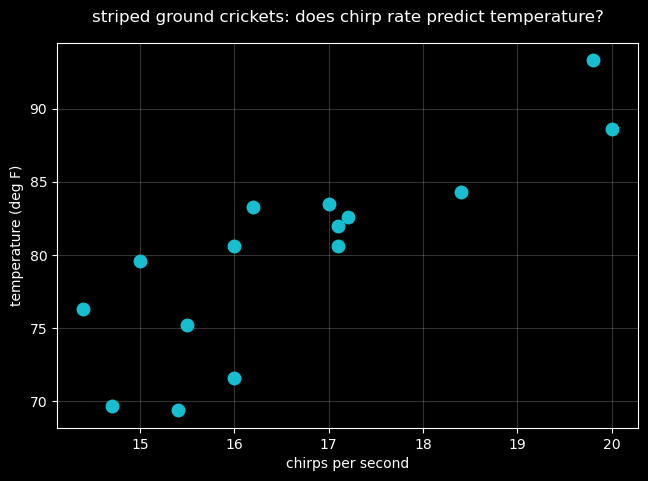

In [3]:
x = crickets['chirps'].values
y = crickets['temperature'].values

fig, ax = plt.subplots(figsize=(7.5, 5))
ax.plot(x, y, "o", color="tab:cyan", markersize=9)
ax.set_xlabel("chirps per second")
ax.set_ylabel("temperature (deg F)")
ax.set_title("striped ground crickets: does chirp rate predict temperature?", pad=15)
ax.grid(alpha=0.2)
plt.show()

## 2. Three candidate lines

Any two numbers $(b_0, b_1)$ define a line. Here are three plausible guesses. They all pass through
the cloud, and by eye it is genuinely hard to say which is best.

That difficulty is the point: **"looks about right" is not a definition**. We need a number.

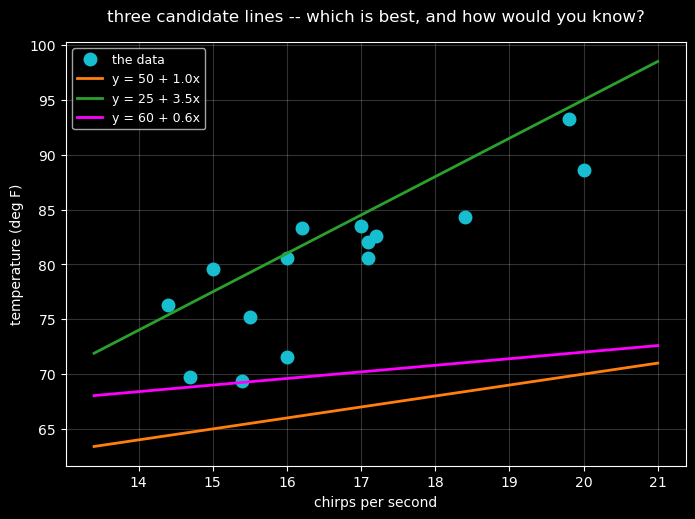

In [4]:
candidates = [(50.0, 1.0, "tab:orange"),
              (25.0, 3.5, "tab:green"),
              (60.0, 0.6, "magenta")]

grid = np.linspace(x.min() - 1, x.max() + 1, 100)

fig, ax = plt.subplots(figsize=(8, 5.5))
ax.plot(x, y, "o", color="tab:cyan", markersize=9, label="the data")
for b0, b1, c in candidates:
    ax.plot(grid, b0 + b1*grid, color=c, lw=2, label=f"y = {b0:.0f} + {b1:.1f}x")
ax.set_xlabel("chirps per second")
ax.set_ylabel("temperature (deg F)")
ax.legend(fontsize=9)
ax.grid(alpha=0.2)
ax.set_title("three candidate lines -- which is best, and how would you know?", pad=15)
plt.show()

## 3. Residuals, and why we square

For each point, the **residual** is the vertical distance from the point to the line. Draw them and
the comparison becomes visual: the best line is the one with the smallest gaps overall.

Why not just add the residuals up? Because they carry signs, and a line that misses badly in both
directions can total nearly zero. The middle column below shows exactly that failure. **Squaring**
removes the signs and additionally penalizes one big miss more than several small ones.

In [5]:
def residuals(b0, b1):
    return y - (b0 + b1*x)

print(f"{'line':>22} {'sum of residuals':>18} {'sum of SQUARED residuals':>26}")
print("-" * 70)
for b0, b1, _ in candidates:
    e = residuals(b0, b1)
    print(f"{'y = %.0f + %.1fx' % (b0, b1):>22} {e.sum():18.3f} {np.sum(e**2):26.3f}")
print("-" * 70)

                  line   sum of residuals   sum of SQUARED residuals
----------------------------------------------------------------------
         y = 50 + 1.0x            200.800                   3091.480
         y = 25 + 3.5x            -48.700                    350.430
         y = 60 + 0.6x            150.720                   1998.698
----------------------------------------------------------------------


The middle column is the one to distrust. A **plain sum of residuals** is misleading, because positive and negative misses cancel, a badly placed line can total near zero. The **sum of squared residuals** in the right-hand column is the honest score, and lower is better.


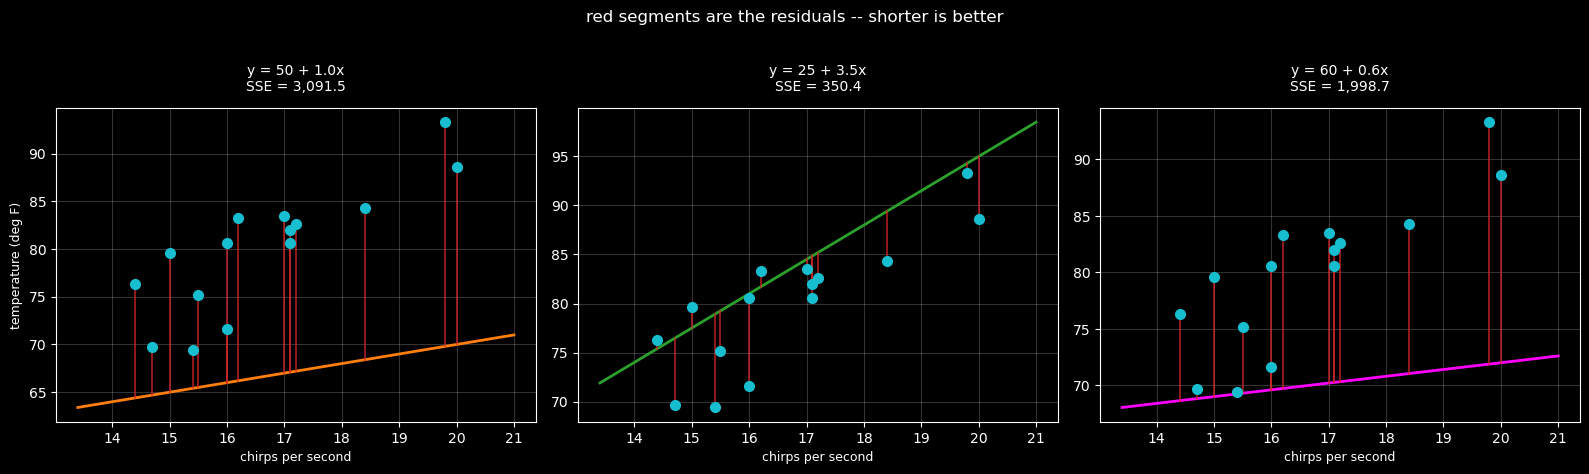

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))
for ax, (b0, b1, c) in zip(axes, candidates):
    ax.plot(x, y, "o", color="tab:cyan", markersize=7, zorder=5)
    ax.plot(grid, b0 + b1*grid, color=c, lw=2)
    for xi, yi in zip(x, y):
        ax.plot([xi, xi], [yi, b0 + b1*xi], "-", color="tab:red", lw=1.2, alpha=0.8)
    sse = np.sum(residuals(b0, b1)**2)
    ax.set_xlabel("chirps per second", fontsize=9)
    ax.set_title(f"y = {b0:.0f} + {b1:.1f}x\nSSE = {sse:,.1f}", pad=12, fontsize=10)
    ax.grid(alpha=0.2)
axes[0].set_ylabel("temperature (deg F)", fontsize=9)
plt.suptitle("red segments are the residuals -- shorter is better", y=1.02)
plt.tight_layout()
plt.show()

## 4. The least-squares line

Now that "best" means "smallest sum of squared residuals," there is a unique answer, and it has a
closed form. Using the deviations from each mean:

$$b_1 = \frac{\sum (x_i - \bar{x})(y_i - \bar{y})}{\sum (x_i - \bar{x})^2}, \qquad b_0 = \bar{y} - b_1\bar{x}$$

The numerator of $b_1$ measures how $x$ and $y$ vary *together*; the denominator measures how $x$
varies on its own. (Where these formulas come from, minimizing SSE with calculus, is `U3-7_Regression-4_MatrixForm`, once
the matrix machinery is set up. `U3-7_Regression-3_ThreeWays` also finds the same line by
gradient descent.)

In [7]:
x_bar, y_bar = x.mean(), y.mean()

s_xy = np.sum((x - x_bar) * (y - y_bar))     # how x and y vary together
s_xx = np.sum((x - x_bar)**2)                # how x varies on its own

b1 = s_xy / s_xx
b0 = y_bar - b1*x_bar

print(f"mean chirps      x_bar = {x_bar:.4f}")
print(f"mean temperature y_bar = {y_bar:.4f}")
print(f"s_xy = {s_xy:.4f}")
print(f"s_xx = {s_xx:.4f}\n")
print(f"slope     b1 = s_xy / s_xx      = {b1:.4f}")
print(f"intercept b0 = y_bar - b1 x_bar = {b0:.4f}\n")
print(f"the fitted line:  temperature = {b0:.3f} + {b1:.3f} x chirps")

mean chirps      x_bar = 16.6533
mean temperature y_bar = 80.0400
s_xy = 133.4780
s_xx = 40.5573

slope     b1 = s_xy / s_xx      = 3.2911
intercept b0 = y_bar - b1 x_bar = 25.2323

the fitted line:  temperature = 25.232 + 3.291 x chirps


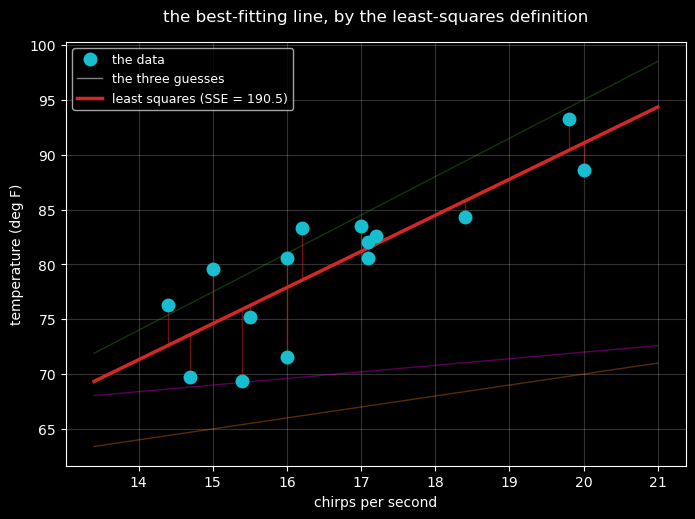

                      line          SSE
----------------------------------------
             y = 50 + 1.0x      3091.48
             y = 25 + 3.5x       350.43
             y = 60 + 0.6x      1998.70
             LEAST SQUARES       190.55   <- the smallest possible


In [8]:
sse_best = np.sum(residuals(b0, b1)**2)

fig, ax = plt.subplots(figsize=(8, 5.5))
ax.plot(x, y, "o", color="tab:cyan", markersize=9, zorder=5, label="the data")
for b0c, b1c, c in candidates:
    ax.plot(grid, b0c + b1c*grid, color=c, lw=1, alpha=0.35)
ax.plot([], [], color="gray", lw=1, label="the three guesses")
ax.plot(grid, b0 + b1*grid, color="tab:red", lw=2.5, label=f"least squares (SSE = {sse_best:.1f})")
for xi, yi in zip(x, y):
    ax.plot([xi, xi], [yi, b0 + b1*xi], "-", color="tab:red", lw=1, alpha=0.5)

ax.set_xlabel("chirps per second")
ax.set_ylabel("temperature (deg F)")
ax.legend(fontsize=9)
ax.grid(alpha=0.2)
ax.set_title("the best-fitting line, by the least-squares definition", pad=15)
plt.show()

print(f"{'line':>26} {'SSE':>12}")
print("-" * 40)
for b0c, b1c, _ in candidates:
    print(f"{'y = %.0f + %.1fx' % (b0c, b1c):>26} {np.sum(residuals(b0c, b1c)**2):12.2f}")
print(f"{'LEAST SQUARES':>26} {sse_best:12.2f}   <- the smallest possible")

In [9]:
# is it really the smallest? try a grid of nearby lines and check none beats it
b0s = np.linspace(b0 - 15, b0 + 15, 120)
b1s = np.linspace(b1 - 2, b1 + 2, 120)
best_found = min(np.sum((y - (i + s*x))**2) for i in b0s for s in b1s)
print(f"best SSE found by brute force over 14,400 nearby lines: {best_found:.3f}")
print(f"SSE of the closed-form answer:                          {sse_best:.3f}")

best SSE found by brute force over 14,400 nearby lines: 190.678
SSE of the closed-form answer:                          190.547


Nothing nearby does better. The closed-form answer really is the minimum, not merely a good guess.


## 5. Summary

- A straight-line model $y = b_0 + b_1 x$ has two parameters: **intercept** and **slope**.
- A **residual** is the vertical gap between an observed point and the line.
- Residuals are **squared** before adding, because raw residuals cancel and squaring punishes big
  misses more.
- Minimizing $\text{SSE} = \sum e_i^2$ is the **least-squares** criterion, and it has a closed-form
  answer: $b_1 = s_{xy}/s_{xx}$, $b_0 = \bar{y} - b_1\bar{x}$.
- "Best fit" is a **definition**, not an aesthetic judgment, and a different definition would give a
  different line.

Next: having fitted a line, how good is it? (`U3-7_Regression-2_HowGoodIsTheFit`).